# Test 4: Event Localization using Bisection Search

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

from syssimx.core.events import Event
from syssimx.system.connection import EventConnection
from syssimx.system.system import System

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import thesis.plot_setup as plot_setup

plt = plot_setup.set_professional_style()

print(repo_root)
sys.path.insert(0, str(repo_root / "demos/ControlledPendulum/MyModels"))
from EQB.hybrid_fmu_pendulum import Pendulum

/home/flo/code/SystemSimulation


In [2]:
# 1) Create pendulum component
pendulum = Pendulum(name="pendulum")
pendulum.set_parameters(q0=0.3)


# 2) Define event indicator function
def event_indicator_function(comp: Pendulum) -> float:
    """Event indicator: pendulum angle (triggers when q=0)"""
    return comp.get_outputs()["q"].magnitude


# 3) Initialize component and add event indicator
pendulum.initialize(t0=0.0)

event = Event(name="wall_hit", source=pendulum.name, direction=-1)
pendulum.add_event_indicator(event.name, event_indicator_function, direction=event.direction)
pendulum.subscribe_event(event=event)

# 4) Create system with single component
system = System(name="Single Pendulum Test")
system.add_component(pendulum)

# 5) Add event connections (event source to event input)
event_connection = EventConnection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["wall_hit"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["omega_invert"].name,
)
system.add_event_connection(event_connection)

# 6) Initialize system (will auto-select HybridAlgorithm)
system.initialize(t0=0.0)
system.algorithm.record_internal_steps = True

print(f"Algorithm selected: {system.algorithm.name}")
print(f"Event sources: {[c.name for c in system.event_sources]}")
print(f"Event listeners: {[c.name for c in system.event_listeners]}")
print(f"Event targets: {system._event_targets_by_source}")

Algorithm selected: Hybrid-Algorithm
Event sources: ['pendulum']
Event listeners: ['pendulum']
Event targets: {('pendulum', 'wall_hit'): ['pendulum']}


In [4]:
for name, value in pendulum.parameters.items():
    print(f"{name}: {value}")

L: 0.6055028481722639 m
g: 9.81 m/s²
inertia: 18.90035177381065 kg·m²
m: 41.70369562497543 kg
omega0: 0.0 rad/s
q0: 0.3 rad


In [5]:
# 6) Run simulation with event detection
t_start = 0.0
t_end = 1.0
dt = 0.01  # Macro step size

system.run(t0=t_start, tf=t_end, dt=dt)

Time: 0.4300 s
Events detected in interval [0.43000000, 0.44000000]
Crossings: [('pendulum', 'wall_hit')]
Located at t=(0.43633930, 0)
Already handled events: set()

Handling events at (0.43633930, 0): [('pendulum', 'wall_hit')]

Events grouped by component for handling: {'pendulum': ['wall_hit']}

Dispatching event 'wall_hit' from 'pendulum' to targets: ['pendulum']



In [6]:
# 7) Extract and plot results
history = system.get_history()
pendulum_history = history["pendulum"]
event_history = history["Events"]

t_vals, data = pendulum_history
q_vals = data["q"]
omega_vals = data["omega"]

# Get event times
event_times = event_history.get(("pendulum", "wall_hit"), [])
t_event = event_times[0] if event_times else None

print(f"\nDetected {len(event_times)} events")
if t_event:
    print(f"First event at t = {t_event.t:.8f} s")


Detected 1 events
First event at t = 0.43633930 s


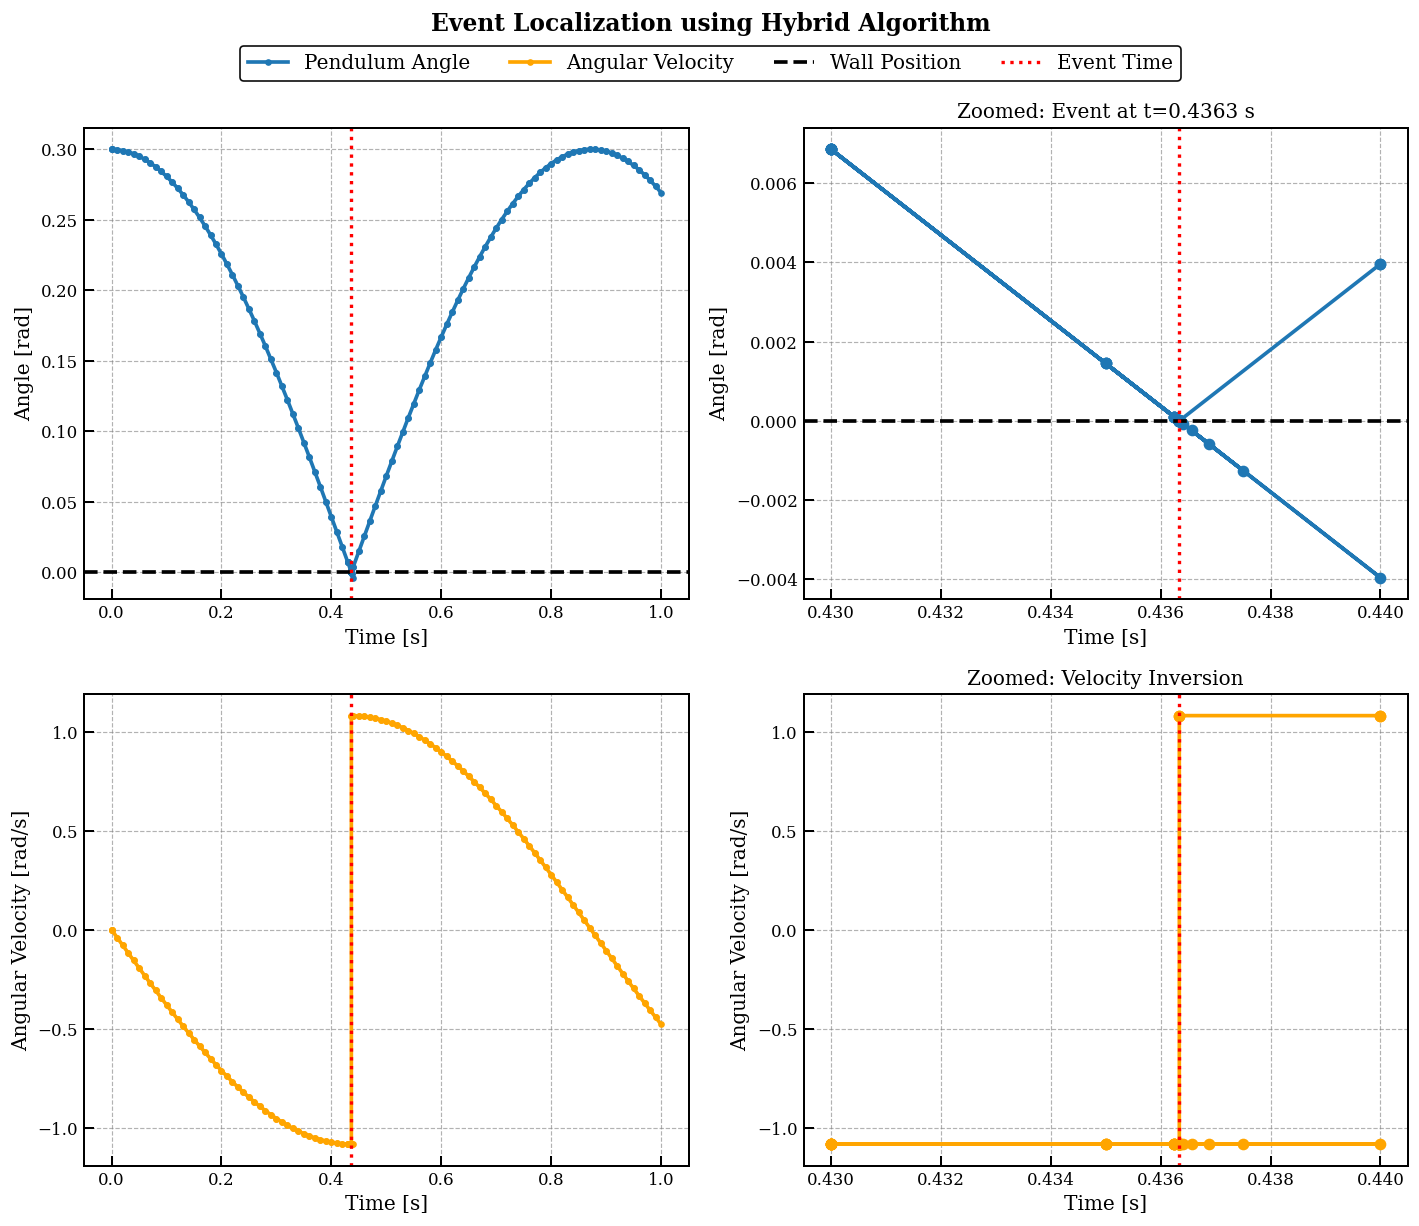

In [7]:
# 8) Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Event Localization using Hybrid Algorithm", fontweight="bold", fontsize=14, y=1.02)

# Top left: Full angle trajectory
(line1,) = axs[0, 0].plot(t_vals, q_vals, label="Pendulum Angle", marker="o", markersize=3)
line2 = axs[0, 0].axhline(0, color="k", linestyle="--", label="Wall Position")
if t_event:
    line3 = axs[0, 0].axvline(
        t_event.t, color="red", linestyle=":", linewidth=2, label="Event Time"
    )
axs[0, 0].set_xlabel("Time [s]")
axs[0, 0].set_ylabel("Angle [rad]")
axs[0, 0].grid()

# Top right: Zoomed angle near event
if t_event:
    zoom_window = 0.01
    mask = (t_vals >= t_event.t - zoom_window) & (t_vals <= t_event.t + zoom_window)
    axs[0, 1].plot(t_vals[mask], q_vals[mask], "o-", markersize=6)
    axs[0, 1].axhline(0, color="k", linestyle="--")
    axs[0, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[0, 1].set_xlabel("Time [s]")
    axs[0, 1].set_ylabel("Angle [rad]")
    axs[0, 1].set_title(f"Zoomed: Event at t={t_event.t:.4f} s")
    axs[0, 1].grid()

# Bottom left: Full angular velocity
(line4,) = axs[1, 0].plot(
    t_vals, omega_vals, color="orange", label="Angular Velocity", marker="o", markersize=3
)
if t_event:
    axs[1, 0].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
axs[1, 0].set_xlabel("Time [s]")
axs[1, 0].set_ylabel("Angular Velocity [rad/s]")
axs[1, 0].grid()

# Bottom right: Zoomed velocity near event
if t_event:
    axs[1, 1].plot(t_vals[mask], omega_vals[mask], "o-", color="orange", markersize=6)
    axs[1, 1].axvline(t_event.t, color="red", linestyle=":", linewidth=2)
    axs[1, 1].set_xlabel("Time [s]")
    axs[1, 1].set_ylabel("Angular Velocity [rad/s]")
    axs[1, 1].set_title("Zoomed: Velocity Inversion")
    axs[1, 1].grid()

signals = [line1, line4, line2, line3]
labels = [s.get_label() for s in signals if s is not None]
fig.legend(signals, labels, loc="upper center", bbox_to_anchor=(0.5, 1), ncol=4)

plt.tight_layout()
plt.savefig("../figures/Hybrid/test_2_location.svg")
plt.show()